<a href="https://colab.research.google.com/github/va23274/CI345_ML/blob/main/Lab8_KNN_MovieStore_finished_By_Arsilbhai_vahora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab08 KNN
## Arsilbhai vahora

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# **lab 8 - knn classification for Video data**
## 5-6-2026
### Arsilbhai vahora ☣





In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Step 1: Loading and Anazlyza Data

In [ ]:
from google.colab import drive

#Mount Google Drive
drive.mount('/content/drive')

# Path to your CSV in Drive
video_store_file = '/content/drive/MyDrive/CI345_ML/data/Video_Store.csv'

orginal_vtable = pd.read_csv(video_store_file)
orginal_vtable.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No
2,3,F,32000,20,42,1.6,Comedy,No


In [ ]:
df = orginal_vtable
print(df.shape)
print('-----')
df.columns




(50, 8)
-----


Index(['Cust ID', 'Gender', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Genre',
       'Like'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cust ID      50 non-null     int64  
 1   Gender       50 non-null     object 
 2   Income       50 non-null     int64  
 3   Age          50 non-null     int64  
 4   Rentals      50 non-null     int64  
 5   AvgPerVisit  50 non-null     float64
 6   Genre        50 non-null     object 
 7   Like         50 non-null     object 
dtypes: float64(1), int64(4), object(3)
memory usage: 3.3+ KB


In [ ]:
df.dtypes

,0
Cust ID,int64
Gender,object
Income,int64
Age,int64
Rentals,int64
AvgPerVisit,float64
Genre,object
Like,object


In [ ]:
df.isnull().sum()

,0
Cust ID,0
Gender,0
Income,0
Age,0
Rentals,0
AvgPerVisit,0
Genre,0
Like,0


In [ ]:
vtable = df
vtable['Income'] = vtable['Income'].astype(float)
print(vtable.dtypes)


Cust ID          int64
Gender          object
Income         float64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre           object
Like            object
dtype: object


In [ ]:
print(df['Income'].describe())
print('------------------------')
df[['Income', 'Age', 'Rentals']].describe()


count       50.000000
mean     42300.000000
std      21409.753642
min       1000.000000
25%      26750.000000
50%      41000.000000
75%      56750.000000
max      89000.000000
Name: Income, dtype: float64
------------------------


,Income,Age,Rentals
count,50.000000,50.000000,50.000000
mean,42300.000000,31.560000,26.320000
std,21409.753642,12.000272,10.047723
min,1000.000000,15.000000,9.000000
25%,26750.000000,22.000000,19.000000
50%,41000.000000,30.000000,25.000000
75%,56750.000000,37.500000,32.000000
max,89000.000000,70.000000,48.000000


In [ ]:
df = orginal_vtable
df.head(2)

,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,M,45000,25,32,2.5,Action,Yes
1,2,F,54000,33,12,3.4,Drama,No


## Step 2 : Data Visualization

Genre
Drama     20
Action    18
Comedy    12
Name: count, dtype: int64


<Axes: title={'center': 'Genre'}, xlabel='Genre'>

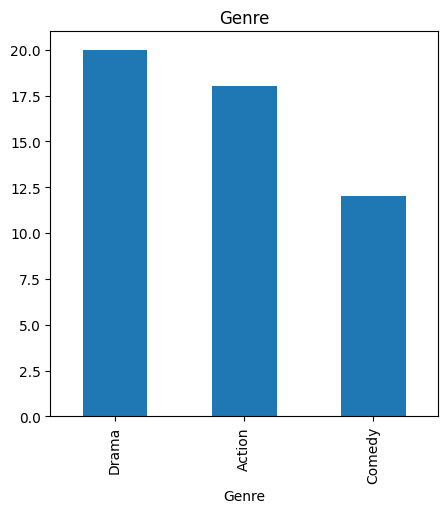

In [ ]:
res = df.Genre.value_counts()
print(res)
res.plot(kind='bar', title = 'Genre', figsize = (5,5))


<Axes: title={'center': 'Income'}, ylabel='Frequency'>

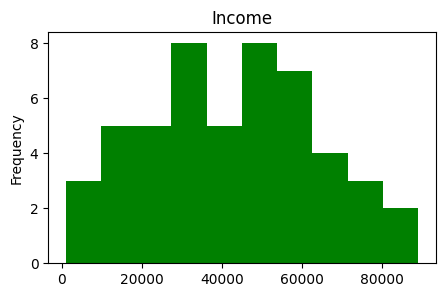

In [ ]:
df = orginal_vtable
res = df['Income']
res.plot(kind='hist',bins = 10, title = 'Income', color= 'green', figsize =( 5,3))

<Axes: ylabel='count'>

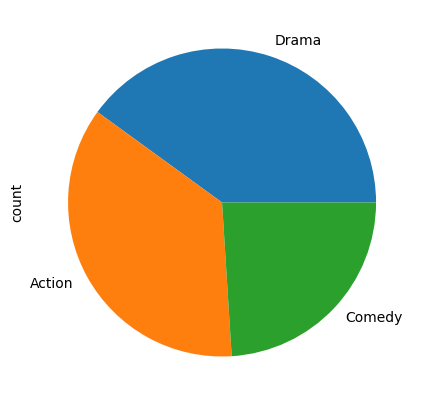

In [ ]:
res = df['Genre'].value_counts()
res.plot(kind='pie', figsize = (5,5))


array([[<Axes: title={'center': 'Income'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Rentals'}>,
        <Axes: title={'center': 'AvgPerVisit'}>]], dtype=object)

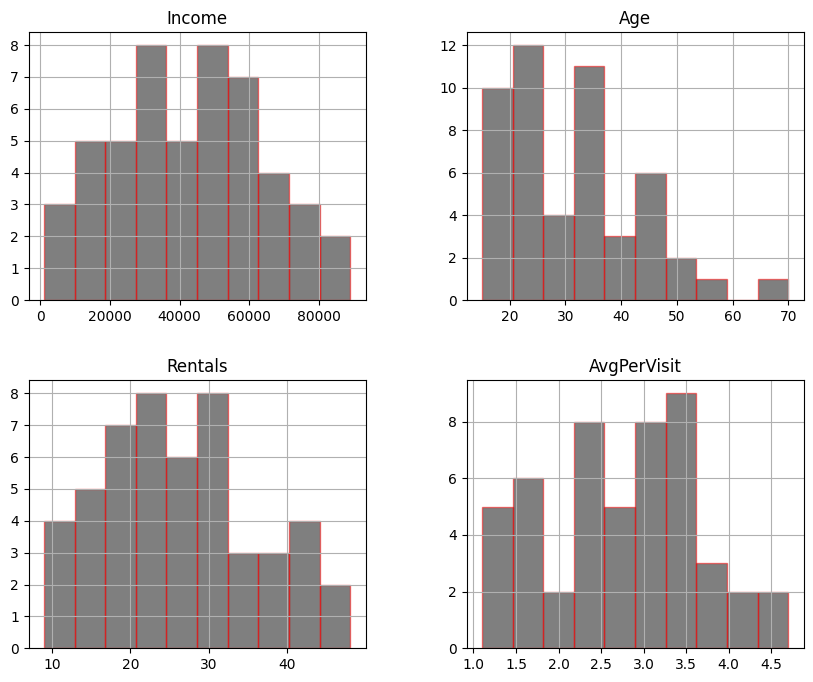

In [ ]:

df = orginal_vtable
res = df[['Income','Age','Rentals','AvgPerVisit']]
res
res.hist(alpha = 0.5, edgecolor='red', color = 'black', figsize = (10,8))


In [ ]:
res = df['Like'].value_counts()


## Step 3: Data processing
## Convert Categorical data to numerical
### Method 1 : Using Colab

In [ ]:
print(df.shape)
df.head(2)

(50, 8)


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2.5,0,1
1,2,0,54000,33,12,3.4,2,0


In [ ]:
# Need Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 1 : Using LabelEncoder
# Problem: model may think numbers have order (0 < 1 < 2)
# Use mainly for target labels (y), not features

print('--------')
df = orginal_vtable
from sklearn.preprocessing import LabelEncoder

# All category feature need to transfer to numeric feature
le = LabelEncoder()
df['Gender']= le.fit_transform(df['Gender'])
df['Genre']= le.fit_transform(df['Genre'])
df['Like']= le.fit_transform(df['Like'])
print(df.dtypes)
print(df.head(2))

# vs Method


print(df.dtypes)
df.head(2)

--------
Cust ID          int64
Gender           int64
Income           int64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object
   Cust ID  Gender  Income  Age  Rentals  AvgPerVisit  Genre  Like
0        1       1   45000   25       32          2.5      0     1
1        2       0   54000   33       12          3.4      2     0
Cust ID          int64
Gender           int64
Income           int64
Age              int64
Rentals          int64
AvgPerVisit    float64
Genre            int64
Like             int64
dtype: object


,Cust ID,Gender,Income,Age,Rentals,AvgPerVisit,Genre,Like
0,1,1,45000,25,32,2.5,0,1
1,2,0,54000,33,12,3.4,2,0


In [ ]:
# Current process data has not category

vtable_after_LabelEncoder = df
# Seperate data part
v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]
# Get target
v_target = vtable['Like']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 6)
(50,)


,Gender,Income,Age,Rentals,AvgPerVisit,Genre
0,1,45000,25,32,2.5,0
1,0,54000,33,12,3.4,2
2,0,32000,20,42,1.6,1


## Step 4 : KNN Classfication

In [41]:
# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier

n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 8)
(10, 8)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

------ Confusion Matrix
[[3 4]
 [0 3]]



# Converting categoric feature to numerical feature

## Method 2 : Using get_dummies -

In [ ]:
orginal_vtable = pd.read_csv(video_store_file)
df = orginal_vtable
print(df.head(2))

   Cust ID Gender  Income  Age  Rentals  AvgPerVisit   Genre Like
0        1      M   45000   25       32          2.5  Action  Yes
1        2      F   54000   33       12          3.4   Drama   No


In [ ]:
# Data Processomg
# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies

gender_df= pd.get_dummies(df['Gender'])

v_matrix = pd.get_dummies(orginal_vtable)
print(v_matrix.dtypes)
print(v_matrix.head(2))

v_matrix = v_matrix.astype(int)
print(v_matrix.head(2))

# Problem : numberical features also changed !!!!


   Cust ID Gender  Income  Age  Rentals  AvgPerVisit   Genre Like
0        1      M   45000   25       32          2.5  Action  Yes
1        2      F   54000   33       12          3.4   Drama   No
Cust ID           int64
Income            int64
Age               int64
Rentals           int64
AvgPerVisit     float64
Gender_F           bool
Gender_M           bool
Genre_Action       bool
Genre_Comedy       bool
Genre_Drama        bool
Like_No            bool
Like_Yes           bool
dtype: object
   Cust ID  Income  Age  Rentals  AvgPerVisit  Gender_F  Gender_M  \
0        1   45000   25       32          2.5     False      True   
1        2   54000   33       12          3.4      True     False   

   Genre_Action  Genre_Comedy  Genre_Drama  Like_No  Like_Yes  
0          True         False        False    False      True  
1         False         False         True     True     False  
   Cust ID  Income  Age  Rentals  AvgPerVisit  Gender_F  Gender_M  \
0        1   45000   25       3

## Step 5 : Converting Categorical

In [38]:

# Convert Converting categoric feature to numerical feature

# Method 2 : Using get_dummies -
category_cols = ['Gender', 'Genre', 'Like']
df_use_dummies = pd.get_dummies(df, columns = category_cols, dtype= int)
print("---")
print(df_use_dummies.dtypes)
print(df_use_dummies.head(2))



---
Cust ID           int64
Income            int64
Age               int64
Rentals           int64
AvgPerVisit     float64
Gender_F          int64
Gender_M          int64
Genre_Action      int64
Genre_Comedy      int64
Genre_Drama       int64
Like_No           int64
Like_Yes          int64
dtype: object
   Cust ID  Income  Age  Rentals  AvgPerVisit  Gender_F  Gender_M  \
0        1   45000   25       32          2.5         0         1   
1        2   54000   33       12          3.4         1         0   

   Genre_Action  Genre_Comedy  Genre_Drama  Like_No  Like_Yes  
0             1             0            0        0         1  
1             0             0            1        1         0  


In [39]:
df_use_dummies.shape

(50, 12)

In [40]:
# Current process data has not category

vtable = df_use_dummies
# Seperate data part
v_data = vtable[['Income','Age','Rentals', 'AvgPerVisit','Gender_F',	'Genre_Action','Genre_Comedy','Genre_Drama']]
# Get target
v_target = vtable['Like_Yes']

print(v_data.shape)
print(v_target.shape)
v_data.head(3)

(50, 8)
(50,)


,Income,Age,Rentals,AvgPerVisit,Gender_F,Genre_Action,Genre_Comedy,Genre_Drama
0,45000,25,32,2.5,0,1,0,0
1,54000,33,12,3.4,1,0,0,1
2,32000,20,42,1.6,1,0,1,0


In [47]:
# Seperate data and target, after use dummies

all_cols = df_use_dummies.columns.tolist()
print(all_cols)

size = len(all_cols)
#print(size)

data_cols =all_cols [0:(size-2)]
#print(data_cols)
#print(df_use_dummies.columns[0:(size-2)] )

# Seperate data part
# v_data = vtable[['Gender','Income','Age','Rentals', 'AvgPerVisit','Genre']]

# Get target


print(v_data.shape)
print(v_target.shape)


['Cust ID', 'Income', 'Age', 'Rentals', 'AvgPerVisit', 'Gender_F', 'Gender_M', 'Genre_Action', 'Genre_Comedy', 'Genre_Drama', 'Like_No', 'Like_Yes']
(50, 8)
(50,)


In [48]:
v_data.head(2)

,Income,Age,Rentals,AvgPerVisit,Gender_F,Genre_Action,Genre_Comedy,Genre_Drama
0,45000,25,32,2.5,0,1,0,0
1,54000,33,12,3.4,1,0,0,1


In [49]:
v_target.head(2)

,Like_Yes
0,1
1,0


In [50]:
data_train.describe()

,Income,Age,Rentals,AvgPerVisit,Gender_F,Genre_Action,Genre_Comedy,Genre_Drama
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,42075.000000,31.800000,26.725000,2.812500,0.475000,0.400000,0.175000,0.425000
std,20391.536077,12.002564,9.771721,0.867708,0.505736,0.496139,0.384808,0.500641
min,1000.000000,16.000000,11.000000,1.400000,0.000000,0.000000,0.000000,0.000000
25%,25750.000000,23.500000,19.000000,2.200000,0.000000,0.000000,0.000000,0.000000
50%,43000.000000,30.000000,25.500000,2.850000,0.000000,0.000000,0.000000,0.000000
75%,56000.000000,35.250000,32.250000,3.325000,1.000000,1.000000,0.000000,1.000000
max,83000.000000,70.000000,48.000000,4.700000,1.000000,1.000000,1.000000,1.000000


In [52]:
# After using use_dummies

# Step 3: Split Dataset
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test  = train_test_split (v_data, v_target, random_state = 11, test_size = 0.2)

# What is the output
print(data_train.shape)
print(data_test.shape)

print(target_train.shape)
print(target_test.shape)

# Step 4: Create a KNN classifier
from sklearn.neighbors import KNeighborsClassifier
n_neighbors = 3
knn_classifier = KNeighborsClassifier(n_neighbors, weights = 'distance')
print(knn_classifier)

#Training the KNN classifier
knn_classifier.fit (X = data_train, y = target_train)
#print(knn_classifier)

# Step 5: Testing
predicted = knn_classifier.predict(X= data_test)

# Step 6: Evaluation
# Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)

#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print('------ Confusion Matrix')
print(matrix)

(40, 8)
(10, 8)
(40,)
(10,)
KNeighborsClassifier(n_neighbors=3, weights='distance')
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10

------ Confusion Matrix
[[3 4]
 [0 3]]


# Convert categoric feature to numerical feature

## Method 3 : Using HotOneEncoder


In [ ]:
#use scores method
score = knn_classifier.score(v_test_norm, target_test)
score

In [ ]:
#Use Confusion_matrix
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(y_true = target_test, y_pred = predicted)
print(matrix)

In [ ]:
#Classification report
from sklearn.metrics import classification_report
report = classification_report(target_test, predicted)
print(report)